# Proje 3: Aşırı Öğrenme Kum Havuzu — Düzenlileştiricilerin Karşılaştırmalı Analizi

Bu notebook'ta Fashion-MNIST veri setinden küçük bir alt küme alarak **aşırı öğrenme (overfitting)** oluşturacak ve farklı **düzenlileştirme (regularization)** tekniklerinin etkisini karşılaştıracağız.

**Deneyler:**
1. **Baseline** — Düzenlileştirmesiz model
2. **L2 (Weight Decay)** — Ağırlık cezalandırma
3. **Dropout** — Rastgele nöron kapatma
4. **Early Stopping** — Erken durdurma

In [1]:
import sys
import os

# Proje kok dizinini Python yoluna ekle
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.18.1
GPU available: False


## 1. Hiperparametreler ve Ayarlar

In [2]:
SUBSET_SIZE = 1000
VALIDATION_SPLIT = 0.2
RANDOM_SEED = 42

INPUT_SHAPE = (28, 28, 1)
NUM_CLASSES = 10
HIDDEN_UNITS = [256, 128]

EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 1e-3

L2_LAMBDA = 0.01
DROPOUT_RATE = 0.5
EARLY_STOPPING_PATIENCE = 5

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

EXPERIMENT_NAMES = {
    "baseline": "Baseline (Duzenlilestirmesiz)",
    "l2": "L2 Duzenlilestirme",
    "dropout": "Dropout",
    "early_stopping": "Early Stopping",
}

RESULTS_DIR = os.path.join("..", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Ayarlar yuklendi.")

Ayarlar yuklendi.


## 2. Veri Yukleme ve On Isleme

Fashion-MNIST veri setini yukluyoruz ve overfitting'i garanti altina almak icin egitim setinden sadece **1000 ornek** aliyoruz.

In [3]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

np.random.seed(RANDOM_SEED)
indices = np.random.choice(len(x_train_full), size=SUBSET_SIZE, replace=False)
x_train = x_train_full[indices]
y_train = y_train_full[indices]

print(f"Egitim alt kumesi boyutu : {x_train.shape}")
print(f"Test seti boyutu         : {x_test.shape}")

Egitim alt kumesi boyutu : (1000, 28, 28, 1)
Test seti boyutu         : (10000, 28, 28, 1)


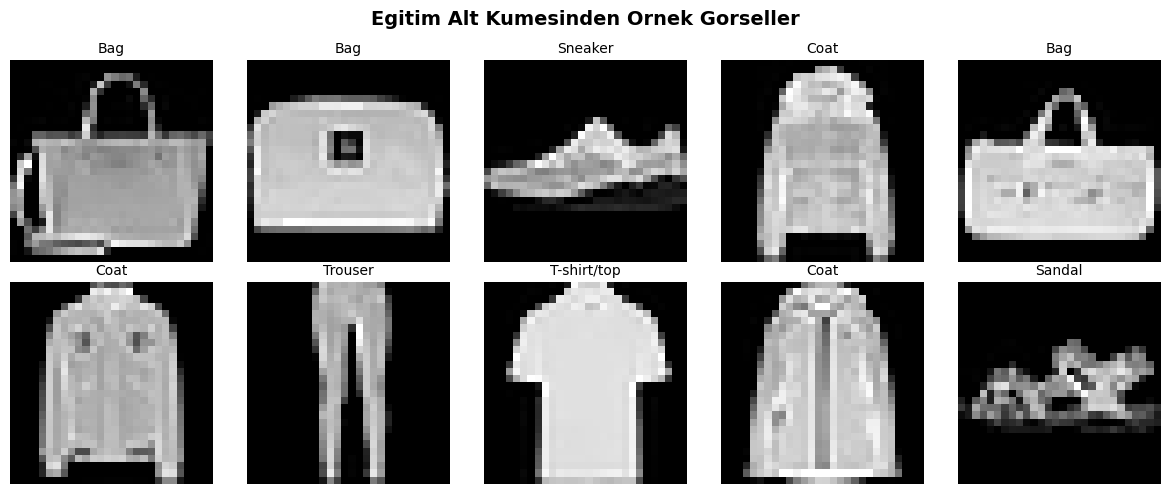

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].squeeze(), cmap="gray")
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Egitim Alt Kumesinden Ornek Gorseller", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Model Mimarileri

Tum modeller ayni temel yapiya sahiptir: `Flatten -> Dense(256) -> Dense(128) -> Dense(10)`. Fark sadece duzenlilestirme teknigindedir.

In [5]:
def build_baseline_model():
    """Duzenlilestirmesiz temel model."""
    model = models.Sequential([
        layers.Flatten(input_shape=INPUT_SHAPE),
        layers.Dense(HIDDEN_UNITS[0], activation="relu"),
        layers.Dense(HIDDEN_UNITS[1], activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    return model


def build_l2_model():
    """L2 (Weight Decay) duzenlilestirmeli model."""
    model = models.Sequential([
        layers.Flatten(input_shape=INPUT_SHAPE),
        layers.Dense(HIDDEN_UNITS[0], activation="relu",
                     kernel_regularizer=regularizers.l2(L2_LAMBDA)),
        layers.Dense(HIDDEN_UNITS[1], activation="relu",
                     kernel_regularizer=regularizers.l2(L2_LAMBDA)),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    return model


def build_dropout_model():
    """Dropout duzenlilestirmeli model."""
    model = models.Sequential([
        layers.Flatten(input_shape=INPUT_SHAPE),
        layers.Dense(HIDDEN_UNITS[0], activation="relu"),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(HIDDEN_UNITS[1], activation="relu"),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    return model


def build_early_stopping_model():
    """Early Stopping ile kullanilacak model (mimarisi baseline ile ayni)."""
    return build_baseline_model()


MODEL_BUILDERS = {
    "baseline": build_baseline_model,
    "l2": build_l2_model,
    "dropout": build_dropout_model,
    "early_stopping": build_early_stopping_model,
}

sample_model = build_baseline_model()
sample_model.summary()

c:\Users\kuti\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Egitim

Her deney icin modeli olusturup egitiyoruz. Early Stopping deneyinde `EarlyStopping` callback kullanilir.

In [6]:
def train_experiment(experiment_name):
    """Belirtilen deneyi calistirir ve (model, history) dondurur."""
    print(f"\n{'='*60}")
    print(f"  Deney: {EXPERIMENT_NAMES[experiment_name]}")
    print(f"{'='*60}")

    model = MODEL_BUILDERS[experiment_name]()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = []
    if experiment_name == "early_stopping":
        callbacks.append(EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ))

    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=callbacks,
        verbose=0,
    )

    final_epoch = len(history.history['loss'])
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    print(f"  Toplam epoch: {final_epoch} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return model, history

In [7]:
results = {}
for name in MODEL_BUILDERS:
    model, history = train_experiment(name)
    results[name] = (model, history)

print("\nTum deneyler tamamlandi!")


  Deney: Baseline (Duzenlilestirmesiz)
  Toplam epoch: 100 | Train Acc: 1.0000 | Val Acc: 0.8000

  Deney: L2 Duzenlilestirme
  Toplam epoch: 100 | Train Acc: 0.9413 | Val Acc: 0.7750

  Deney: Dropout
  Toplam epoch: 100 | Train Acc: 0.9613 | Val Acc: 0.7800

  Deney: Early Stopping
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.
  Toplam epoch: 11 | Train Acc: 0.8975 | Val Acc: 0.8000

Tum deneyler tamamlandi!


## 5. Degerlendirme

Tum modelleri test seti uzerinde degerlendirip sonuclari karsilastiriyoruz.

In [8]:
print(f"{'='*60}")
print("  TEST SETI SONUCLARI")
print(f"{'='*60}")

metrics = {}
for name, (model, _) in results.items():
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    metrics[name] = (test_loss, test_acc)
    print(f"[{EXPERIMENT_NAMES[name]}]  Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}")

best_name = max(metrics, key=lambda k: metrics[k][1])
print(f"\nEn iyi model: {EXPERIMENT_NAMES[best_name]} (Accuracy: {metrics[best_name][1]:.4f})")

  TEST SETI SONUCLARI
[Baseline (Duzenlilestirmesiz)]  Test Loss: 1.2572  |  Test Accuracy: 0.8149
[L2 Duzenlilestirme]  Test Loss: 0.8583  |  Test Accuracy: 0.7959
[Dropout]  Test Loss: 1.0111  |  Test Accuracy: 0.8050
[Early Stopping]  Test Loss: 0.6473  |  Test Accuracy: 0.7823

En iyi model: Baseline (Duzenlilestirmesiz) (Accuracy: 0.8149)


## 6. Gorsellestirme

### 6.1 Her Deney Icin Egitim Egrileri

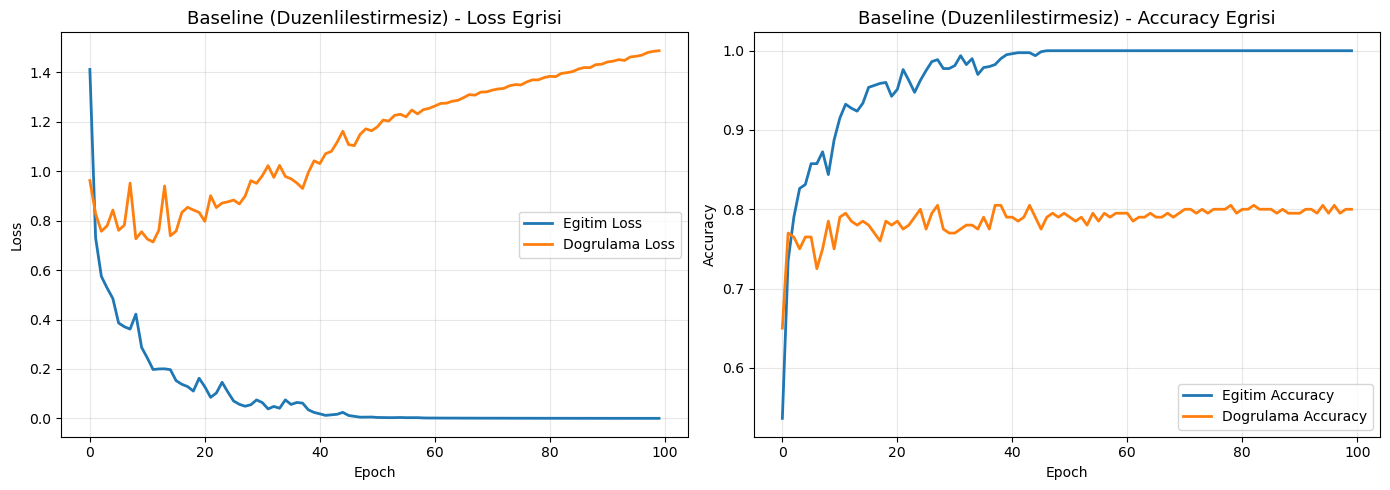

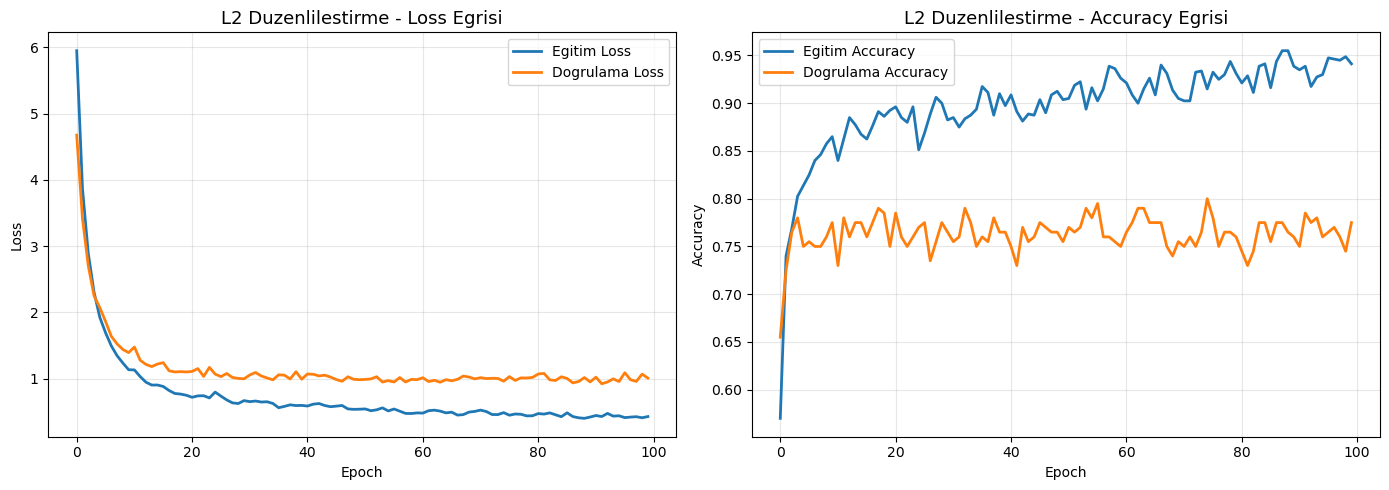

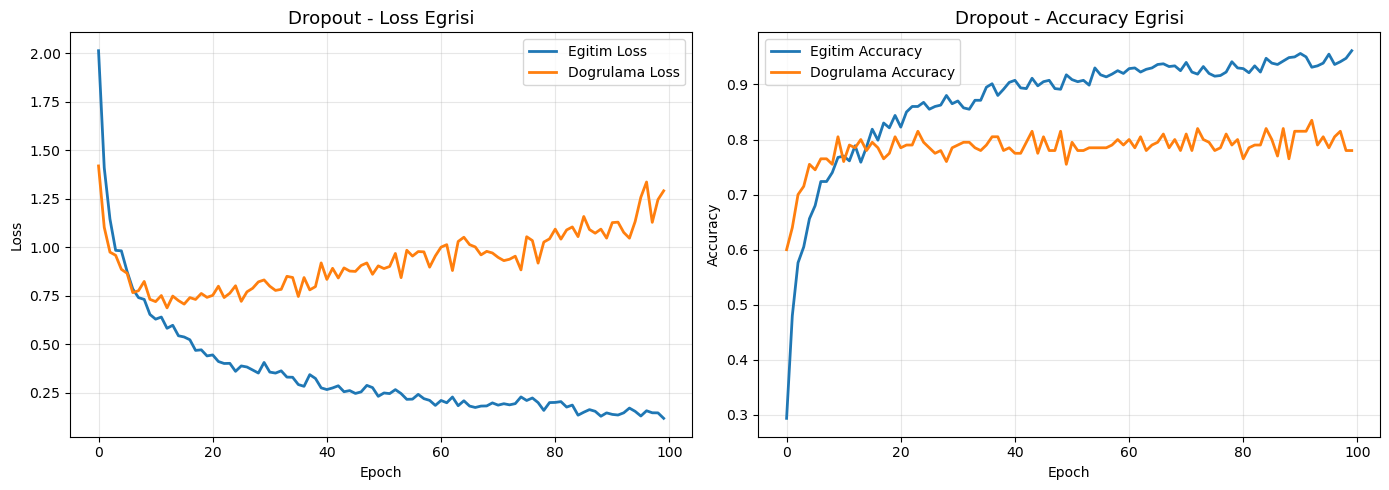

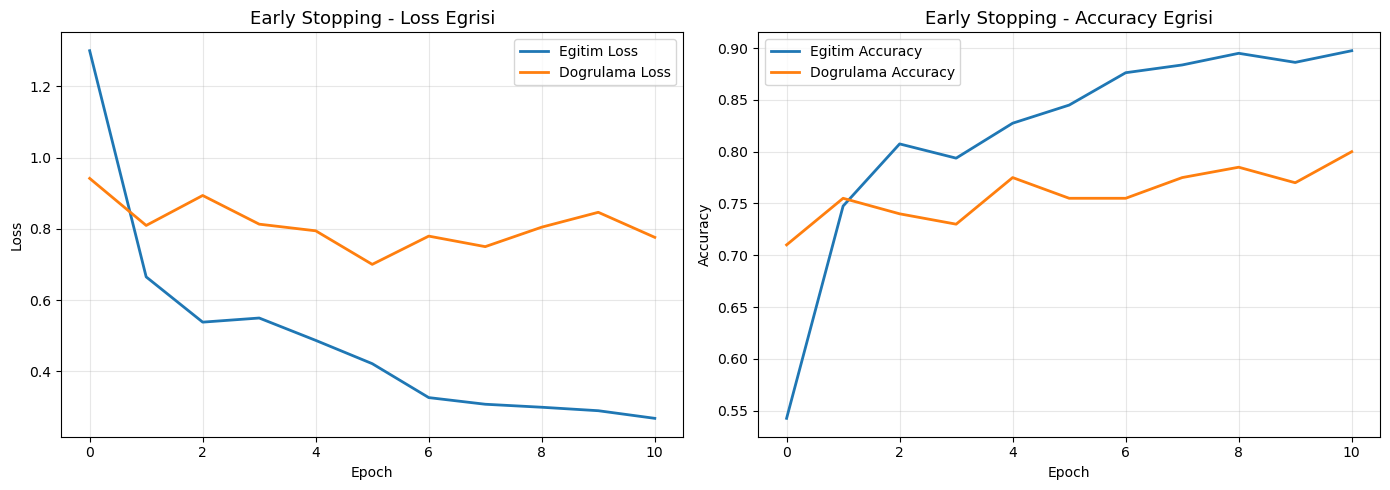

In [9]:
for name, (_, history) in results.items():
    title = EXPERIMENT_NAMES[name]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history["loss"], label="Egitim Loss", linewidth=2)
    ax1.plot(history.history["val_loss"], label="Dogrulama Loss", linewidth=2)
    ax1.set_title(f"{title} - Loss Egrisi", fontsize=13)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history["accuracy"], label="Egitim Accuracy", linewidth=2)
    ax2.plot(history.history["val_accuracy"], label="Dogrulama Accuracy", linewidth=2)
    ax2.set_title(f"{title} - Accuracy Egrisi", fontsize=13)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, f"{name}_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()

### 6.2 Tum Deneylerin Karsilastirmasi

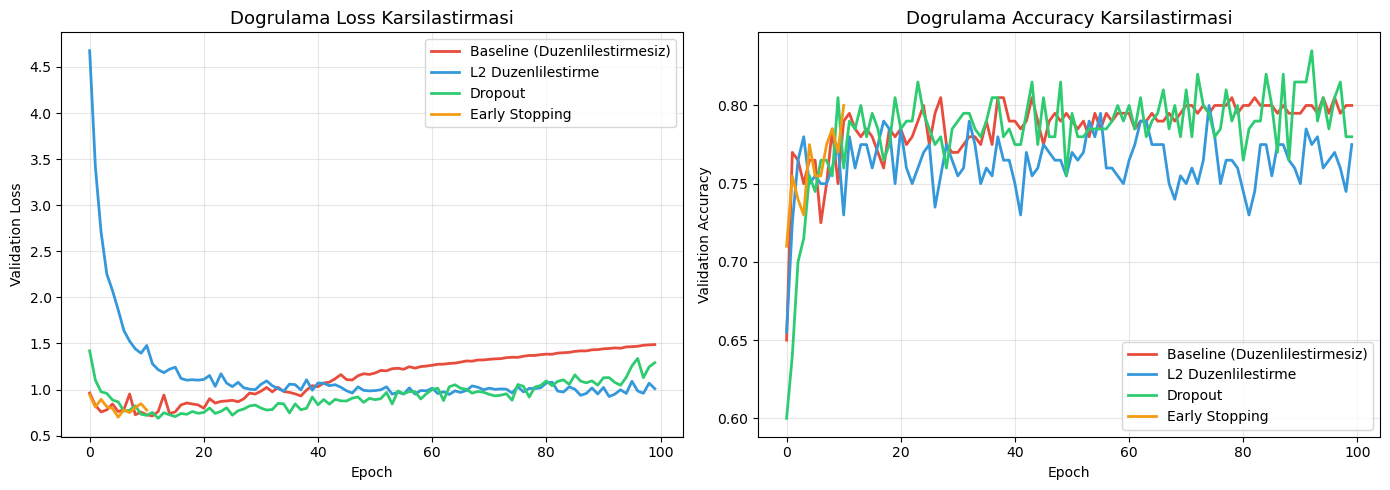

In [10]:
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, (_, history)) in enumerate(results.items()):
    label = EXPERIMENT_NAMES[name]
    ax1.plot(history.history["val_loss"], label=label, linewidth=2, color=colors[i])
    ax2.plot(history.history["val_accuracy"], label=label, linewidth=2, color=colors[i])

ax1.set_title("Dogrulama Loss Karsilastirmasi", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title("Dogrulama Accuracy Karsilastirmasi", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "comparison_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6.3 Test Accuracy Karsilastirma Bar Chart

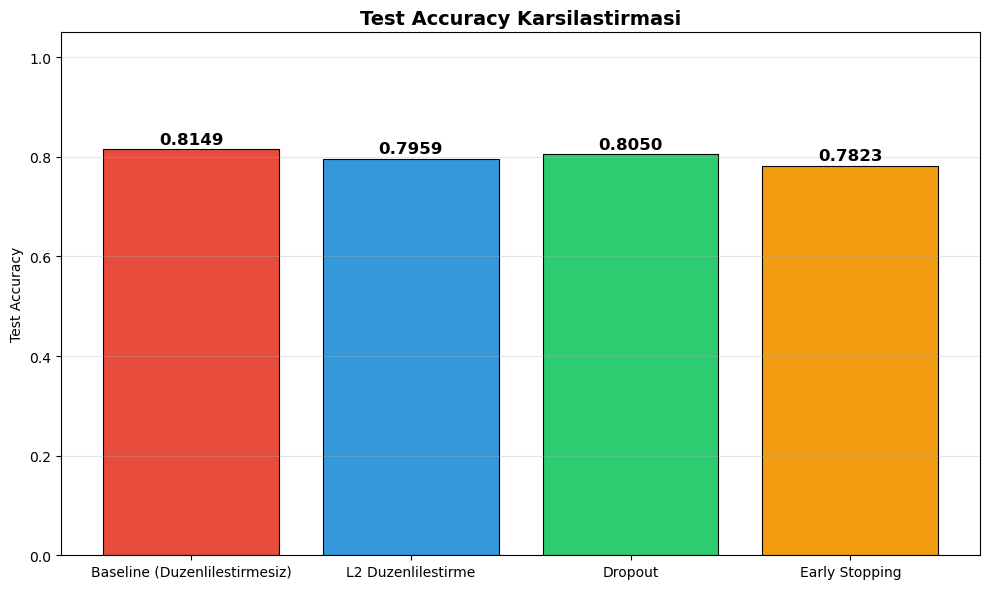

In [11]:
names_display = [EXPERIMENT_NAMES[k] for k in metrics]
accuracies = [metrics[k][1] for k in metrics]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(names_display, accuracies, color=colors, edgecolor="black", linewidth=0.8)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{acc:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Test Accuracy Karsilastirmasi", fontsize=14, fontweight="bold")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "test_accuracy_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6.4 Confusion Matrix (En Iyi Model)

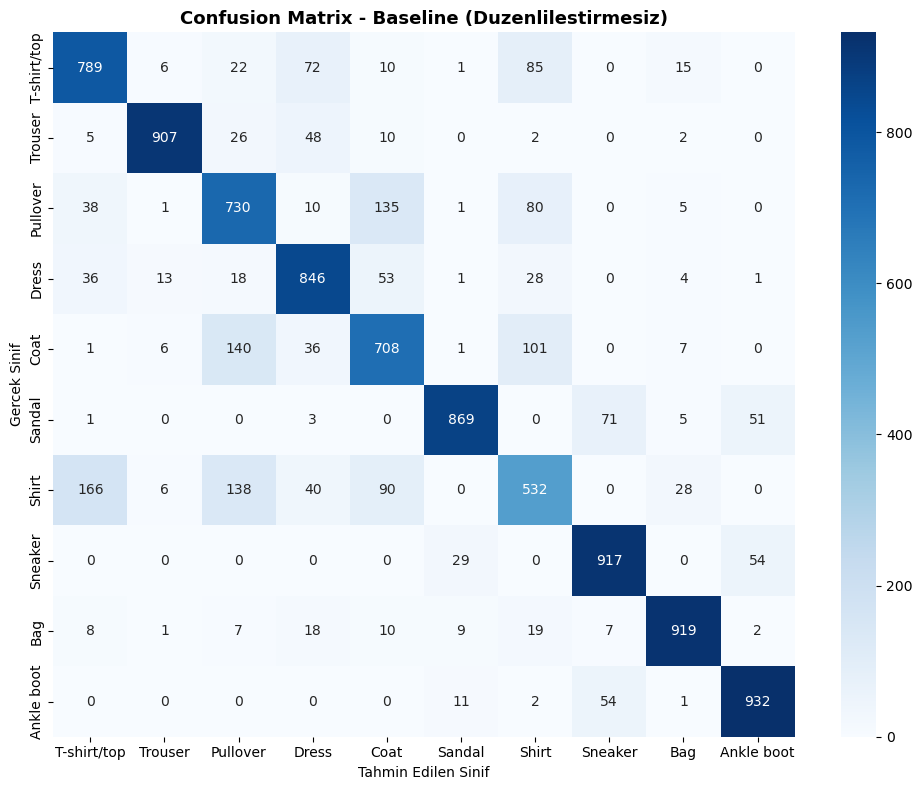

In [12]:
best_model = results[best_name][0]
y_pred = best_model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f"Confusion Matrix - {EXPERIMENT_NAMES[best_name]}", fontsize=13, fontweight="bold")
ax.set_xlabel("Tahmin Edilen Sinif")
ax.set_ylabel("Gercek Sinif")
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

In [13]:
print(f"\nClassification Report ({EXPERIMENT_NAMES[best_name]}):\n")
print(classification_report(y_test, y_pred_classes, target_names=CLASS_NAMES, digits=4))


Classification Report (Baseline (Duzenlilestirmesiz)):

              precision    recall  f1-score   support

 T-shirt/top     0.7557    0.7890    0.7720      1000
     Trouser     0.9649    0.9070    0.9351      1000
    Pullover     0.6753    0.7300    0.7016      1000
       Dress     0.7884    0.8460    0.8162      1000
        Coat     0.6969    0.7080    0.7024      1000
      Sandal     0.9425    0.8690    0.9043      1000
       Shirt     0.6266    0.5320    0.5754      1000
     Sneaker     0.8742    0.9170    0.8951      1000
         Bag     0.9320    0.9190    0.9255      1000
  Ankle boot     0.8962    0.9320    0.9137      1000

    accuracy                         0.8149     10000
   macro avg     0.8153    0.8149    0.8141     10000
weighted avg     0.8153    0.8149    0.8141     10000



## 7. Sonuc ve Yorum

- **Baseline** modeli kucuk egitim setini hizla ezberleyerek (egitim accuracy ~1.0) asiri ogrenme gostermistir.
- **L2 duzenlilestirme** agirliklari cezalandirarak modelin genelleme kapasitesini artirmistir.
- **Dropout** egitim sirasinda rastgele noronlari kapatarak modelin tek bir ozellik grubuna bagimli olmasini engellemistir.
- **Early Stopping** dogrulama hatasi artmaya basladiginda egitimi durdurarak overfitting'i onlemistir.